In [1]:
try:
    import catboost as cgb
except:
    !uv pip install catboost
    import catboost as cgb

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


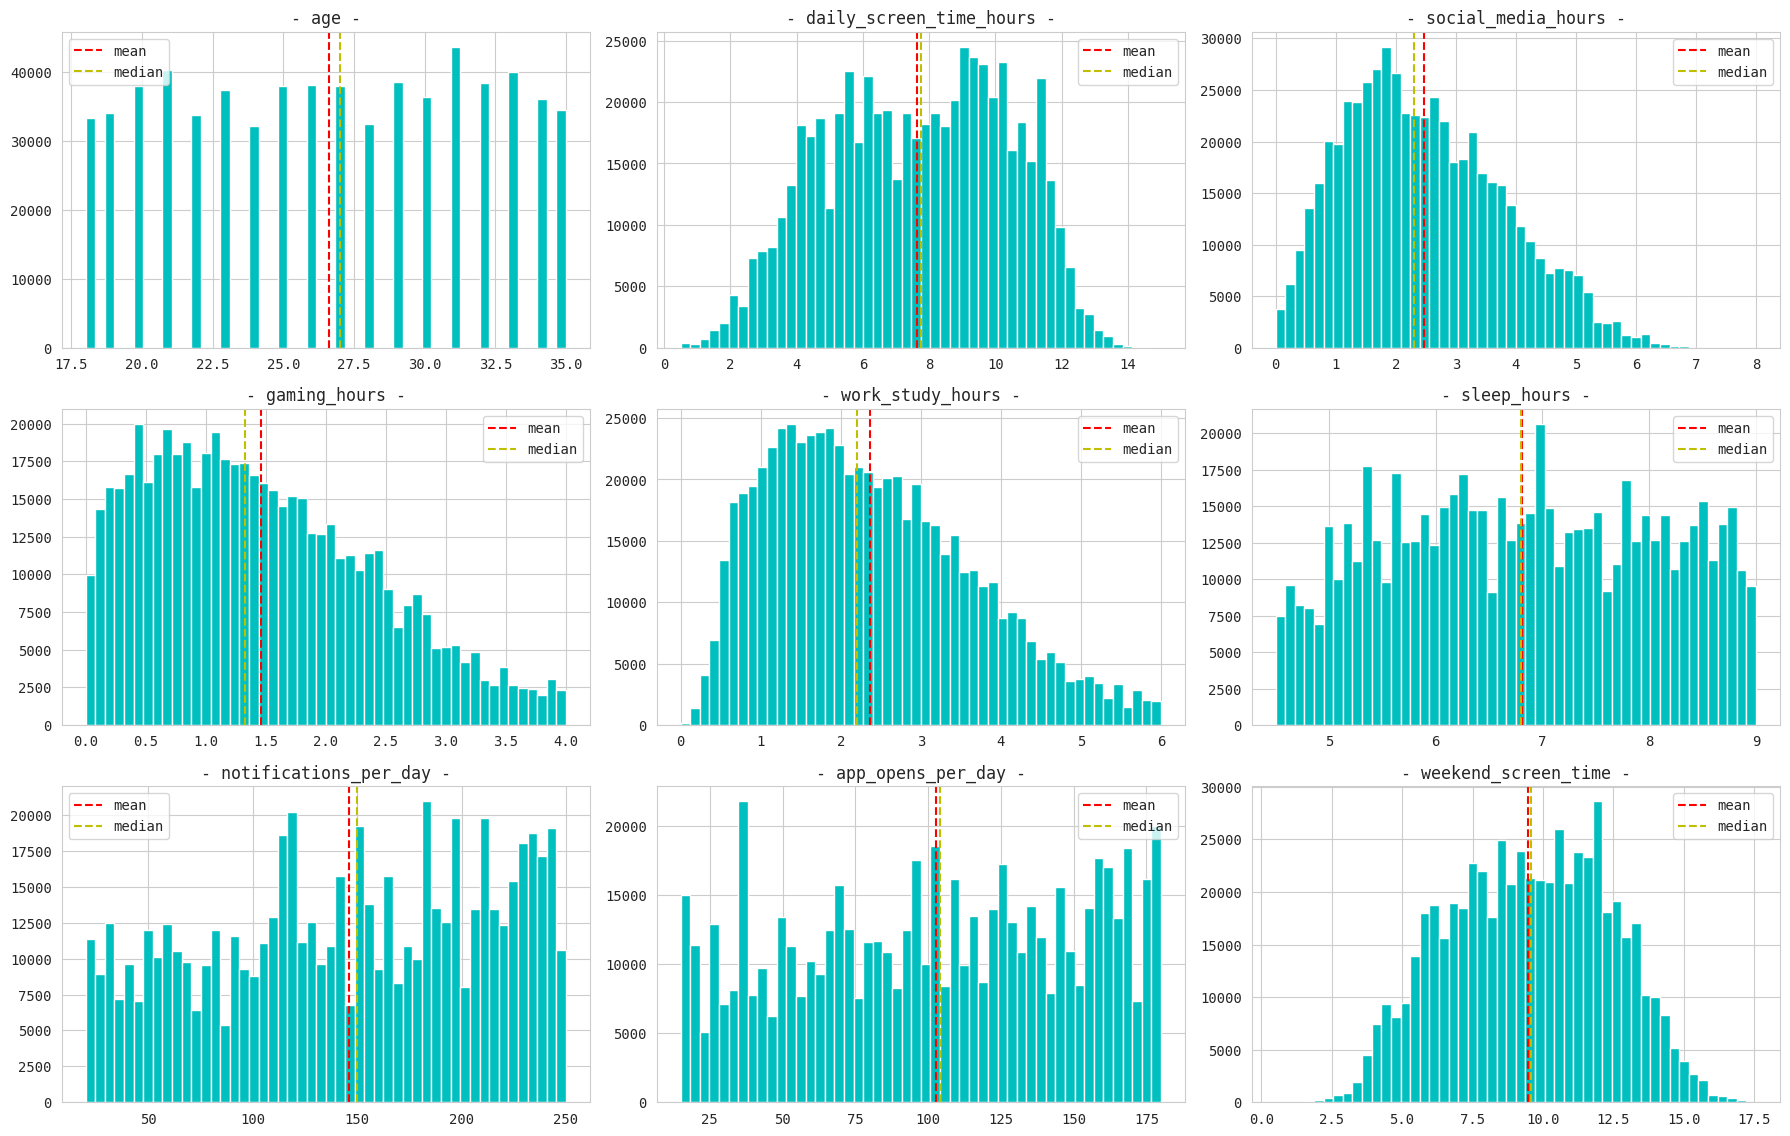

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    num_to_cat = []
    for col in num_features_:
        cat_name = f"{col}_cat"
        df[cat_name] = df[col].fillna('NaN').astype(str)
        num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('float32')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols 

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = [c for c in FE_COLS if c.endswith("_cat")]

# new_cats = ["missing_count", "ci_case", "ci_n_missing"]
# new_cats.extend([
#     c for c in FE_COLS
#     if "_round" in c
#     or c.endswith("_cat")
#     or c.startswith("ci_")
# ])

new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
# NUMS.extend(new_nums)

display(train[FE_COLS].head())

# train[FE_COLS].nunique().sort_values()


,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0
4,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0


In [16]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end="")
for col in NUMS:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
    n = f"{col}_FREQ"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype("float32")
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

train[NUMS+FREQ_COLS]


Creating frequencies... age_FREQ, daily_screen_time_hours_FREQ, social_media_hours_FREQ, gaming_hours_FREQ, work_study_hours_FREQ, sleep_hours_FREQ, notifications_per_day_FREQ, app_opens_per_day_FREQ, weekend_screen_time_FREQ, 
✓ Total frequency features: 9


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0.048841,0.000917,0.002738,0.003255,0.003730,0.003061,0.002960,0.005310,0.001807
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,0.054722,0.001172,0.003309,0.002263,0.000501,0.003874,0.005318,0.009931,0.002690
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,0.046291,0.129266,0.182272,0.187145,0.003060,0.001770,0.102299,0.002160,0.001274
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,0.048841,0.001420,0.001785,0.002101,0.003872,0.001106,0.002876,0.002794,0.001712


In [17]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [19]:
# INTER = []

# inter_cols = ["missing_count", "ci_n_missing", "ci_case"]
# combo_list = list(itertools.combinations(inter_cols + CATS, 2))

# for c1, c2 in tqdm(combo_list, desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# train[INTER].head()

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [22]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["median", "count", "std"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [23]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [24]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS, title="nums_to_cats"):
#     n = f"{c}_cat"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
## ------------------------------------------------------------
## -- Factorize CATS --
for c in tqdm(CATS, desc="factorize_cats"): # +INTER + new_cats
    combined[c] = combined[c].factorize()[0]

# for c in tqdm(CATS, desc="categorize_cats"):
#     combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 65


factorize_cats: 100%|██████████| 3/3 [00:00<00:00, 12.75it/s]


Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,0.048841,0.000917,0.002738,0.003255,0.003730,0.003061,0.002960,0.005310,0.001807,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0

# ML TRAINING

In [25]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
               use_original=False, early_stop=50, print_every=100):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    fold_scores = []
    feature_importances  = []

    # Handle optional original table aggregations securely if flags enable them
    if use_original and "original_TE" in globals():
        feats = features.copy()
        # "mean" for bagging | ("mean", "count", "std", "skew") for goss
        aggs_ = ["mean", "count"] 

        X_tr, orig_cols = original_TE(
            orig, train_data, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_data[features]
        y = train_data[target].astype("int8")
        X_ts = test[features]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.loc[train_idx], X.loc[val_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- TE Opt1. -> Using CUSTOM -- 
        # te_enc  = customTE(new_cats+INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        all_categorical = cat_cols+new_cats #+INTER #.copy()
        
        combined = pd.concat([X_train, X_valid, X_test])
        for c in all_categorical:
            combined[c] = combined[c].astype(str)

        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")
        if idx == 1:
            display(X_train.head())

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=50_000,
            eval_set=dval,
            early_stopping_rounds=early_stop,
            verbose=print_every,
        )

        feature_importances.append(model.get_feature_importance())

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel() / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del dtrain, dval, dtest
        # gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits
    
    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': pd.Series(np.mean(feature_importances, axis=0), index=X_valid.columns),
        # 'imp_pret': feat_imp_pret,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [26]:
VER = f"cat_fe65_"
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1.0,0.048841,0.000917,0.002738,0.003255,0.003730,0.003061,0.002960,0.005310,0.001807,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0

In [27]:
# try:
#     import optuna
# except:
#     !pip install optuna
#     import optuna

# def objective(trial):
#     params = {
#         'boosting_type': 'Plain',
#         'grow_policy': 'SymmetricTree',
#         'bootstrap_type': 'Bayesian',
#         # ---------------------------------
#         # -------------------------------------------------
#         "depth": trial.suggest_int("depth", 3, 10),
#         # -------------------------------------------------
#         # Core Tree Booster Parameters
#         "bagging_temperature": trial.suggest_float("temperature", 0.2, 2.0, step=0.1),
#         "random_strength": trial.suggest_float("strength", 0.6, 1.0, step=0.1),
#         # -------------------------------------------------
#         # Regularization Parameters (Staves off overfitting)
#         "l2_leaf_reg": trial.suggest_float("l2_reg", 1.0, 10.0, log=True),
#         # "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
#         # "colsample_bytree": trial.suggest_float("colsample", 0.3, 1.0, step=0.05),

#         "learning_rate": 0.04,
#         # "learning_rate": trial.suggest_float("lr", 0.05),

#         # Structural Settings
#         'loss_function': 'Logloss',
#         'eval_metric': 'AUC',
#         # 'l2_leaf_reg': L2_REG,
#         # 'depth': 8,
#         # ---------------------------------
#         # 'bagging_temperature': 0.4,
#         # 'random_strength': 0.8,
#         # ---------------------------------
#         'random_state': CFG['SEED'],
#         'verbose': 0,
#         'thread_count': -1,
#         'allow_writing_files': False,
#         'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#     }

#     n = "Optuna"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         cat_cols=ALL_CATS,
#         use_original=True,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # 3. Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="Optuna_Search")

# # Run optimization for 50 trials
# study.optimize(objective, n_trials=30, timeout=3600, show_progress_bar=True)

In [28]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.04 --
# # --- Optimization Complete ---
# # Best Trial ROC-AUC Score: 0.965555
# # Best Hyperparameters:
# # {'depth': 6, 'temperature': 0.30000000000000004, 'l2_reg': 0.10348352129966662}

# --- Optimization Complete ---
# Best Trial ROC-AUC Score: 0.965525
# Best Hyperparameters:
# {'depth': 5, 'temperature': 0.4, 'strength': 0.6, 'l2_reg': 1.2224361482015358}

In [29]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

# ## -- Optimization history across trials
# optuna.visualization.plot_slice(study).show()

# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

In [30]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [31]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [32]:
LR = 0.04
# L2_REG = 2.5
EARLY_STOP   = 100
PRINT_STEPS  = 1500
USE_ORIGINAL = True

LR

0.04

In [33]:
## ========================== BAYESIAN 

bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    'l2_leaf_reg': 1.0,
    # 'depth': 8,
    # ---------------------------------
    'bagging_temperature': 0.4,
    # 'random_strength': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bayes_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    # early_stop=EARLY_STOP,
    # print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe65_bayes | GPU: Tesla T4 =====


Original augment complete!: 100%|██████████| 12/12 [00:04<00:00,  2.75it/s]



+++++ FOLD 1/5 | shape: (553095, 89)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,0.752660,376.0,NaN,NaN,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.712500,400.0,0.333333,9.0,0.555556,18.0,NaN,NaN,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,NaN,NaN,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.671679,399.0,0.294118,17.0,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,NaN,NaN
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,1

Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.9237563	best: 0.9237563 (0)	total: 80.3ms	remaining: 1h 6m 54s
100:	test: 0.9604690	best: 0.9604690 (100)	total: 5.88s	remaining: 48m 27s
200:	test: 0.9633772	best: 0.9633772 (200)	total: 11.9s	remaining: 49m
300:	test: 0.9646669	best: 0.9646669 (300)	total: 17.8s	remaining: 49m 5s
400:	test: 0.9655097	best: 0.9655097 (400)	total: 23.8s	remaining: 49m 5s
500:	test: 0.9660624	best: 0.9660624 (500)	total: 29.8s	remaining: 49m 7s
600:	test: 0.9664300	best: 0.9664300 (600)	total: 35.9s	remaining: 49m 9s
700:	test: 0.9666902	best: 0.9666902 (700)	total: 41.9s	remaining: 49m 8s
800:	test: 0.9669141	best: 0.9669141 (800)	total: 48s	remaining: 49m 7s
900:	test: 0.9670890	best: 0.9670890 (900)	total: 53.9s	remaining: 48m 59s
1000:	test: 0.9672292	best: 0.9672292 (1000)	total: 59.9s	remaining: 48m 52s
1100:	test: 0.9673423	best: 0.9673423 (1100)	total: 1m 5s	remaining: 48m 43s
1200:	test: 0.9674355	best: 0.9674355 (1200)	total: 1m 11s	remaining: 48m 37s
1300:	test: 0.9675152	best: 0.9

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9240868	best: 0.9240868 (0)	total: 80.2ms	remaining: 1h 6m 49s
100:	test: 0.9609417	best: 0.9609417 (100)	total: 5.9s	remaining: 48m 35s
200:	test: 0.9638990	best: 0.9638990 (200)	total: 11.9s	remaining: 49m 10s
300:	test: 0.9651986	best: 0.9651986 (300)	total: 18s	remaining: 49m 29s
400:	test: 0.9660574	best: 0.9660574 (400)	total: 24s	remaining: 49m 32s
500:	test: 0.9666217	best: 0.9666217 (500)	total: 30s	remaining: 49m 26s
600:	test: 0.9669898	best: 0.9669898 (600)	total: 36s	remaining: 49m 21s
700:	test: 0.9672549	best: 0.9672549 (700)	total: 42.1s	remaining: 49m 17s
800:	test: 0.9674402	best: 0.9674402 (800)	total: 48.1s	remaining: 49m 12s
900:	test: 0.9676189	best: 0.9676189 (900)	total: 54.2s	remaining: 49m 14s
1000:	test: 0.9677513	best: 0.9677513 (999)	total: 1m	remaining: 49m 3s
1100:	test: 0.9678615	best: 0.9678615 (1100)	total: 1m 6s	remaining: 48m 58s
1200:	test: 0.9679700	best: 0.9679700 (1200)	total: 1m 12s	remaining: 48m 48s
1300:	test: 0.9680609	best: 0.968

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9221525	best: 0.9221525 (0)	total: 79.4ms	remaining: 1h 6m 11s
100:	test: 0.9595386	best: 0.9595386 (100)	total: 5.96s	remaining: 49m 5s
200:	test: 0.9626853	best: 0.9626853 (200)	total: 11.8s	remaining: 48m 53s
300:	test: 0.9640297	best: 0.9640297 (300)	total: 17.9s	remaining: 49m 13s
400:	test: 0.9649408	best: 0.9649408 (400)	total: 23.9s	remaining: 49m 16s
500:	test: 0.9655994	best: 0.9655994 (500)	total: 30s	remaining: 49m 20s
600:	test: 0.9660186	best: 0.9660186 (600)	total: 36.1s	remaining: 49m 23s
700:	test: 0.9662794	best: 0.9662794 (700)	total: 42.1s	remaining: 49m 19s
800:	test: 0.9665120	best: 0.9665120 (800)	total: 48.1s	remaining: 49m 17s
900:	test: 0.9667039	best: 0.9667039 (900)	total: 54.1s	remaining: 49m 5s
1000:	test: 0.9668721	best: 0.9668721 (1000)	total: 1m	remaining: 49m 3s
1100:	test: 0.9669837	best: 0.9669837 (1100)	total: 1m 6s	remaining: 48m 55s
1200:	test: 0.9670756	best: 0.9670756 (1200)	total: 1m 12s	remaining: 48m 47s
1300:	test: 0.9671751	best:

In [34]:
# lr=0.03 | temperature=0.4 -----------------------|
# Overall AUC: 0.964527
# Average AUC: 0.964539 ± 0.000690
# -------------------------------------------------|
# 23.88 mins

# lr=0.04 | temperature=0.4 -----------------------| 🔥
# Overall AUC: 0.964549
# Average AUC: 0.964559 ± 0.000794
# -------------------------------------------------|
# 20.80 mins

# lr=0.05 | temperature=0.4 -----------------------|
# Overall AUC: 0.96434
# Average AUC: 0.964352 ± 0.000751
# -------------------------------------------------|
# 17.67 mins

In [35]:
# ==================================================
# 5-FOLD CV: cat_TE(84)_bayes | (553095, 84)
# ==================================================
#  • Fold 1 AUC: 0.966638
#  • Fold 2 AUC: 0.967381
#  • Fold 3 AUC: 0.967625
#  • Fold 4 AUC: 0.967941
#  • Fold 5 AUC: 0.967004
# -------------------------------------------------|
# Overall AUC: 0.967317
# Average AUC: 0.967318 ± 0.000458
# -------------------------------------------------|
# 17.24 mins

# ==================================================
# 5-FOLD CV: cat_boostTE(84)_bayes | (553095, 84)
# ==================================================
#  • Fold 1 AUC: 0.966750
#  • Fold 2 AUC: 0.967561
#  • Fold 3 AUC: 0.967626
#  • Fold 4 AUC: 0.968173
#  • Fold 5 AUC: 0.967134
# -------------------------------------------------|
# Overall AUC: 0.967447
# Average AUC: 0.967449 ± 0.000481
# -------------------------------------------------|
# 42.33 mins

In [36]:
# ## =========================== MVS -- ⚠️ OOM issues
# mvs_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     # 'learning_rate': LR,
#     # ---------------------------------
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     # 'depth': 6,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': -1,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = VER+"cat_mvs"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=mvs_params,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     use_orig=USE_ORIGINAL,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
# )

In [37]:
## =========================== BERNOULLI
bern_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    'l2_leaf_reg': 1.0,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Plain",
    'grow_policy': "Depthwise",
    'bootstrap_type': "Bernoulli",
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 80,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bern_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    # early_stop=EARLY_STOP,
    # print_every=PRINT_STEPS
)


===== Starting CV: cat_fe65_bern | GPU: Tesla T4 =====


Original augment complete!: 100%|██████████| 12/12 [00:04<00:00,  2.79it/s]



+++++ FOLD 1/5 | shape: (553095, 89)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,0.752660,376.0,NaN,NaN,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.712500,400.0,0.333333,9.0,0.555556,18.0,NaN,NaN,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,NaN,NaN,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.671679,399.0,0.294118,17.0,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,NaN,NaN
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,1

Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.9414008	best: 0.9414008 (0)	total: 51.1ms	remaining: 42m 33s
100:	test: 0.9623251	best: 0.9623251 (100)	total: 2.96s	remaining: 24m 20s
200:	test: 0.9644020	best: 0.9644020 (200)	total: 5.73s	remaining: 23m 40s
300:	test: 0.9654102	best: 0.9654102 (300)	total: 8.31s	remaining: 22m 52s
400:	test: 0.9659639	best: 0.9659639 (400)	total: 11s	remaining: 22m 42s
500:	test: 0.9663641	best: 0.9663641 (500)	total: 13.7s	remaining: 22m 31s
600:	test: 0.9666214	best: 0.9666214 (600)	total: 16.2s	remaining: 22m 14s
700:	test: 0.9667876	best: 0.9667876 (700)	total: 18.7s	remaining: 21m 58s
800:	test: 0.9669262	best: 0.9669262 (800)	total: 21.4s	remaining: 21m 53s
900:	test: 0.9670422	best: 0.9670438 (899)	total: 23.8s	remaining: 21m 38s
1000:	test: 0.9671419	best: 0.9671420 (999)	total: 26.3s	remaining: 21m 29s
1100:	test: 0.9672072	best: 0.9672077 (1097)	total: 28.9s	remaining: 21m 23s
1200:	test: 0.9672433	best: 0.9672441 (1195)	total: 31.5s	remaining: 21m 19s
1300:	test: 0.9672921	bes

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9412781	best: 0.9412781 (0)	total: 43.5ms	remaining: 36m 12s
100:	test: 0.9627732	best: 0.9627732 (100)	total: 2.75s	remaining: 22m 37s
200:	test: 0.9649104	best: 0.9649104 (200)	total: 5.31s	remaining: 21m 55s
300:	test: 0.9659674	best: 0.9659674 (300)	total: 7.95s	remaining: 21m 52s
400:	test: 0.9665082	best: 0.9665082 (400)	total: 10.6s	remaining: 21m 46s
500:	test: 0.9668097	best: 0.9668097 (500)	total: 13s	remaining: 21m 24s
600:	test: 0.9670912	best: 0.9670912 (600)	total: 15.6s	remaining: 21m 21s
700:	test: 0.9672645	best: 0.9672645 (700)	total: 18.2s	remaining: 21m 21s
800:	test: 0.9674085	best: 0.9674085 (800)	total: 20.9s	remaining: 21m 23s
900:	test: 0.9675140	best: 0.9675140 (900)	total: 23.5s	remaining: 21m 22s
1000:	test: 0.9676061	best: 0.9676062 (998)	total: 26.1s	remaining: 21m 16s
1100:	test: 0.9676759	best: 0.9676759 (1100)	total: 28.7s	remaining: 21m 14s
1200:	test: 0.9677266	best: 0.9677268 (1198)	total: 31.3s	remaining: 21m 13s
1300:	test: 0.9677755	bes

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9402325	best: 0.9402325 (0)	total: 42ms	remaining: 35m 2s
100:	test: 0.9614140	best: 0.9614140 (100)	total: 2.8s	remaining: 23m 2s
200:	test: 0.9636756	best: 0.9636756 (200)	total: 5.32s	remaining: 21m 59s
300:	test: 0.9648542	best: 0.9648542 (300)	total: 7.94s	remaining: 21m 51s
400:	test: 0.9655123	best: 0.9655123 (400)	total: 10.4s	remaining: 21m 26s
500:	test: 0.9659174	best: 0.9659174 (500)	total: 12.9s	remaining: 21m 15s
600:	test: 0.9661699	best: 0.9661699 (600)	total: 15.4s	remaining: 21m 4s
700:	test: 0.9663861	best: 0.9663861 (700)	total: 18s	remaining: 21m 4s
800:	test: 0.9665544	best: 0.9665544 (800)	total: 20.6s	remaining: 21m 2s
900:	test: 0.9666789	best: 0.9666789 (900)	total: 23.2s	remaining: 21m 6s
1000:	test: 0.9667858	best: 0.9667858 (1000)	total: 25.8s	remaining: 21m 2s
1100:	test: 0.9668839	best: 0.9668839 (1100)	total: 28.4s	remaining: 20m 59s
1200:	test: 0.9669619	best: 0.9669621 (1198)	total: 30.9s	remaining: 20m 57s
1300:	test: 0.9670209	best: 0.9670

In [38]:
# 50 -----------------------------------------------|
# Overall AUC: 0.963705
# Average AUC: 0.963724 ± 0.000751
# -------------------------------------------------|
# 6.33 mins

In [39]:
# ==================================================
# 5-FOLD CV: cat_TE_bern
# ==================================================
#  • Fold 1 AUC: 0.966163
#  • Fold 2 AUC: 0.966866
#  • Fold 3 AUC: 0.967248
#  • Fold 4 AUC: 0.967543
#  • Fold 5 AUC: 0.966586
# -------------------------------------------------|
# Overall AUC: 0.96688
# Average AUC: 0.966881 ± 0.000485
# -------------------------------------------------|
# 8.91 mins

In [40]:
## =========================== LOSSGUIDE

loss_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    'l2_leaf_reg': 1.0,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': "Plain",
    'grow_policy': "Lossguide",
    # ---------------------------------
    # 'max_leaves': 64,
    'min_data_in_leaf': 100,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    # early_stop=EARLY_STOP,
    # print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe65_loss | GPU: Tesla T4 =====


Original augment complete!: 100%|██████████| 12/12 [00:04<00:00,  2.80it/s]



+++++ FOLD 1/5 | shape: (553095, 89)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,0.752660,376.0,NaN,NaN,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.712500,400.0,0.333333,9.0,0.555556,18.0,NaN,NaN,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,NaN,NaN,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.671679,399.0,0.294118,17.0,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,NaN,NaN
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,1

Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.9349925	best: 0.9349925 (0)	total: 55.2ms	remaining: 46m 1s
100:	test: 0.9627961	best: 0.9627961 (100)	total: 4.47s	remaining: 36m 47s
200:	test: 0.9647629	best: 0.9647629 (200)	total: 8.53s	remaining: 35m 14s
300:	test: 0.9656290	best: 0.9656290 (300)	total: 12.6s	remaining: 34m 37s
400:	test: 0.9662160	best: 0.9662160 (400)	total: 16.6s	remaining: 34m 18s
500:	test: 0.9665941	best: 0.9665941 (500)	total: 20.7s	remaining: 34m 7s
600:	test: 0.9668633	best: 0.9668633 (600)	total: 24.5s	remaining: 33m 32s
700:	test: 0.9670327	best: 0.9670327 (700)	total: 28.3s	remaining: 33m 9s
800:	test: 0.9671595	best: 0.9671595 (800)	total: 31.7s	remaining: 32m 28s
900:	test: 0.9672836	best: 0.9672836 (900)	total: 35.6s	remaining: 32m 20s
1000:	test: 0.9673715	best: 0.9673715 (1000)	total: 39.7s	remaining: 32m 22s
1100:	test: 0.9674531	best: 0.9674531 (1100)	total: 43.8s	remaining: 32m 24s
1200:	test: 0.9675094	best: 0.9675094 (1200)	total: 48.1s	remaining: 32m 33s
1300:	test: 0.9675696	bes

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9334011	best: 0.9334011 (0)	total: 49.8ms	remaining: 41m 30s
100:	test: 0.9631650	best: 0.9631650 (100)	total: 3.75s	remaining: 30m 54s
200:	test: 0.9651485	best: 0.9651485 (200)	total: 7.38s	remaining: 30m 28s
300:	test: 0.9660718	best: 0.9660718 (300)	total: 10.9s	remaining: 30m 7s
400:	test: 0.9666580	best: 0.9666580 (400)	total: 14.4s	remaining: 29m 37s
500:	test: 0.9670203	best: 0.9670203 (500)	total: 17.7s	remaining: 29m 8s
600:	test: 0.9672751	best: 0.9672751 (600)	total: 21.2s	remaining: 29m 4s
700:	test: 0.9674566	best: 0.9674566 (700)	total: 25.3s	remaining: 29m 38s
800:	test: 0.9675940	best: 0.9675940 (800)	total: 29.4s	remaining: 30m 7s
900:	test: 0.9677055	best: 0.9677055 (900)	total: 33.5s	remaining: 30m 26s
1000:	test: 0.9678115	best: 0.9678115 (1000)	total: 37.5s	remaining: 30m 37s
1100:	test: 0.9678866	best: 0.9678866 (1100)	total: 41.6s	remaining: 30m 48s
1200:	test: 0.9679383	best: 0.9679383 (1200)	total: 45.6s	remaining: 30m 51s
1300:	test: 0.9680013	best

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9325135	best: 0.9325135 (0)	total: 55.3ms	remaining: 46m 3s
100:	test: 0.9619108	best: 0.9619108 (100)	total: 4.36s	remaining: 35m 52s
200:	test: 0.9641098	best: 0.9641098 (200)	total: 8.15s	remaining: 33m 38s
300:	test: 0.9651535	best: 0.9651535 (300)	total: 11.9s	remaining: 32m 47s
400:	test: 0.9658015	best: 0.9658015 (400)	total: 15.6s	remaining: 32m 8s
500:	test: 0.9661815	best: 0.9661815 (500)	total: 18.9s	remaining: 31m 8s
600:	test: 0.9664497	best: 0.9664497 (600)	total: 22.3s	remaining: 30m 31s
700:	test: 0.9666449	best: 0.9666451 (698)	total: 26.1s	remaining: 30m 34s
800:	test: 0.9667744	best: 0.9667744 (800)	total: 30.1s	remaining: 30m 47s
900:	test: 0.9669038	best: 0.9669040 (898)	total: 34.2s	remaining: 31m 5s
1000:	test: 0.9669992	best: 0.9669992 (1000)	total: 38.5s	remaining: 31m 26s
1100:	test: 0.9670783	best: 0.9670783 (1100)	total: 42.9s	remaining: 31m 47s
1200:	test: 0.9671524	best: 0.9671524 (1200)	total: 46.9s	remaining: 31m 47s
1300:	test: 0.9672209	best

In [41]:
# ==================================================
# 5-FOLD CV: cat_TE_loss
# ==================================================
#  • Fold 1 AUC: 0.966239
#  • Fold 2 AUC: 0.967102
#  • Fold 3 AUC: 0.967352
#  • Fold 4 AUC: 0.967591
#  • Fold 5 AUC: 0.966620
# -------------------------------------------------|
# Overall AUC: 0.966981
# Average AUC: 0.966981 ± 0.000491
# -------------------------------------------------|
# 16.69 mins

In [42]:
## =========================== ORDERED 

ord_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    'l2_leaf_reg': 1.0,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'bagging_temperature': 0.4,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "ord_bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ord_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_original=USE_ORIGINAL,
    # early_stop=EARLY_STOP,
    # print_every=PRINT_STEPS,
)


===== Starting CV: cat_fe65_ord_bayes | GPU: Tesla T4 =====


Original augment complete!: 100%|██████████| 12/12 [00:04<00:00,  2.86it/s]



+++++ FOLD 1/5 | shape: (553095, 89)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,0.752660,376.0,NaN,NaN,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.712500,400.0,0.333333,9.0,0.555556,18.0,NaN,NaN,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,NaN,NaN,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.671679,399.0,0.294118,17.0,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,NaN,NaN
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,26.0,1

Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.9237563	best: 0.9237563 (0)	total: 182ms	remaining: 2h 31m 38s
100:	test: 0.9603362	best: 0.9603362 (100)	total: 11.7s	remaining: 1h 36m 11s
200:	test: 0.9633514	best: 0.9633514 (200)	total: 23.1s	remaining: 1h 35m 26s
300:	test: 0.9647119	best: 0.9647119 (300)	total: 34.7s	remaining: 1h 35m 33s
400:	test: 0.9655609	best: 0.9655609 (400)	total: 46.2s	remaining: 1h 35m 12s
500:	test: 0.9660777	best: 0.9660777 (500)	total: 57.6s	remaining: 1h 34m 49s
600:	test: 0.9664569	best: 0.9664569 (600)	total: 1m 8s	remaining: 1h 34m 30s
700:	test: 0.9667078	best: 0.9667078 (700)	total: 1m 20s	remaining: 1h 34m 3s
800:	test: 0.9669077	best: 0.9669077 (800)	total: 1m 31s	remaining: 1h 33m 56s
900:	test: 0.9670280	best: 0.9670280 (900)	total: 1m 43s	remaining: 1h 33m 43s
1000:	test: 0.9671352	best: 0.9671352 (1000)	total: 1m 54s	remaining: 1h 33m 34s
1100:	test: 0.9672269	best: 0.9672269 (1100)	total: 2m 6s	remaining: 1h 33m 25s
1200:	test: 0.9673163	best: 0.9673163 (1200)	total: 2m 17s	re

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9240868	best: 0.9240868 (0)	total: 176ms	remaining: 2h 26m 19s
100:	test: 0.9610215	best: 0.9610215 (100)	total: 11.6s	remaining: 1h 35m 6s
200:	test: 0.9639681	best: 0.9639681 (200)	total: 23s	remaining: 1h 34m 54s
300:	test: 0.9652659	best: 0.9652659 (300)	total: 34.5s	remaining: 1h 35m 3s
400:	test: 0.9660406	best: 0.9660406 (400)	total: 46.1s	remaining: 1h 34m 58s
500:	test: 0.9665993	best: 0.9665993 (500)	total: 57.4s	remaining: 1h 34m 31s
600:	test: 0.9669292	best: 0.9669292 (599)	total: 1m 8s	remaining: 1h 33m 48s
700:	test: 0.9671475	best: 0.9671475 (700)	total: 1m 19s	remaining: 1h 32m 59s
800:	test: 0.9673132	best: 0.9673132 (800)	total: 1m 30s	remaining: 1h 32m 22s
900:	test: 0.9674188	best: 0.9674188 (900)	total: 1m 40s	remaining: 1h 31m 39s
1000:	test: 0.9675555	best: 0.9675555 (1000)	total: 1m 51s	remaining: 1h 31m 19s
1100:	test: 0.9676530	best: 0.9676530 (1100)	total: 2m 2s	remaining: 1h 30m 56s
1200:	test: 0.9677538	best: 0.9677538 (1200)	total: 2m 13s	remai

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9228158	best: 0.9228158 (0)	total: 187ms	remaining: 2h 36m
100:	test: 0.9595778	best: 0.9595778 (100)	total: 11.4s	remaining: 1h 33m 52s
200:	test: 0.9626276	best: 0.9626276 (200)	total: 22.8s	remaining: 1h 34m 1s
300:	test: 0.9640360	best: 0.9640360 (300)	total: 34.3s	remaining: 1h 34m 17s
400:	test: 0.9649322	best: 0.9649322 (400)	total: 45.8s	remaining: 1h 34m 26s
500:	test: 0.9655188	best: 0.9655188 (500)	total: 57.1s	remaining: 1h 34m 1s
600:	test: 0.9658433	best: 0.9658433 (600)	total: 1m 7s	remaining: 1h 33m 5s
700:	test: 0.9660589	best: 0.9660589 (700)	total: 1m 18s	remaining: 1h 32m 16s
800:	test: 0.9662751	best: 0.9662751 (800)	total: 1m 29s	remaining: 1h 31m 50s
900:	test: 0.9664029	best: 0.9664029 (900)	total: 1m 40s	remaining: 1h 31m 9s
1000:	test: 0.9664893	best: 0.9664893 (1000)	total: 1m 50s	remaining: 1h 30m 20s
1100:	test: 0.9666144	best: 0.9666144 (1096)	total: 2m 1s	remaining: 1h 30m 10s
1200:	test: 0.9667018	best: 0.9667018 (1199)	total: 2m 12s	remaining

In [43]:
# ==================================================
# 5-FOLD CV: cat_TE_ordered_bayes
# ==================================================
#  • Fold 1 AUC: 0.966628
#  • Fold 2 AUC: 0.967291
#  • Fold 3 AUC: 0.967751
#  • Fold 4 AUC: 0.967914
#  • Fold 5 AUC: 0.966325
# -------------------------------------------------|
# Overall AUC: 0.967183
# Average AUC: 0.967182 ± 0.000618
# -------------------------------------------------|
# 37.20 mins

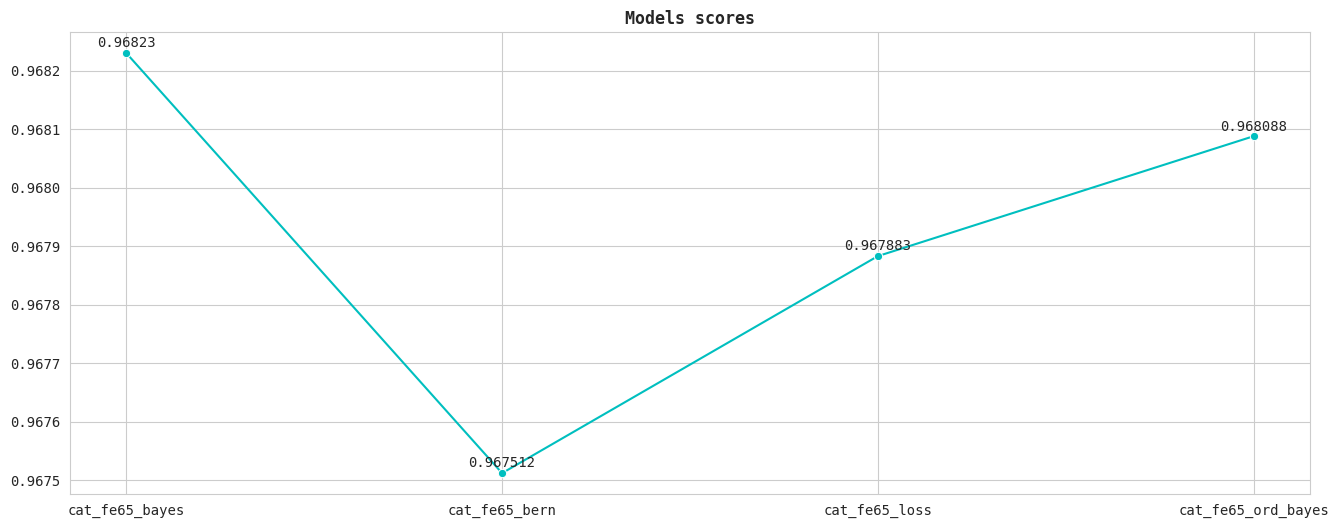

In [44]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-5
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

# plt.tight_layout()
plt.show()

cat_fe65_bayes_96823 saved!


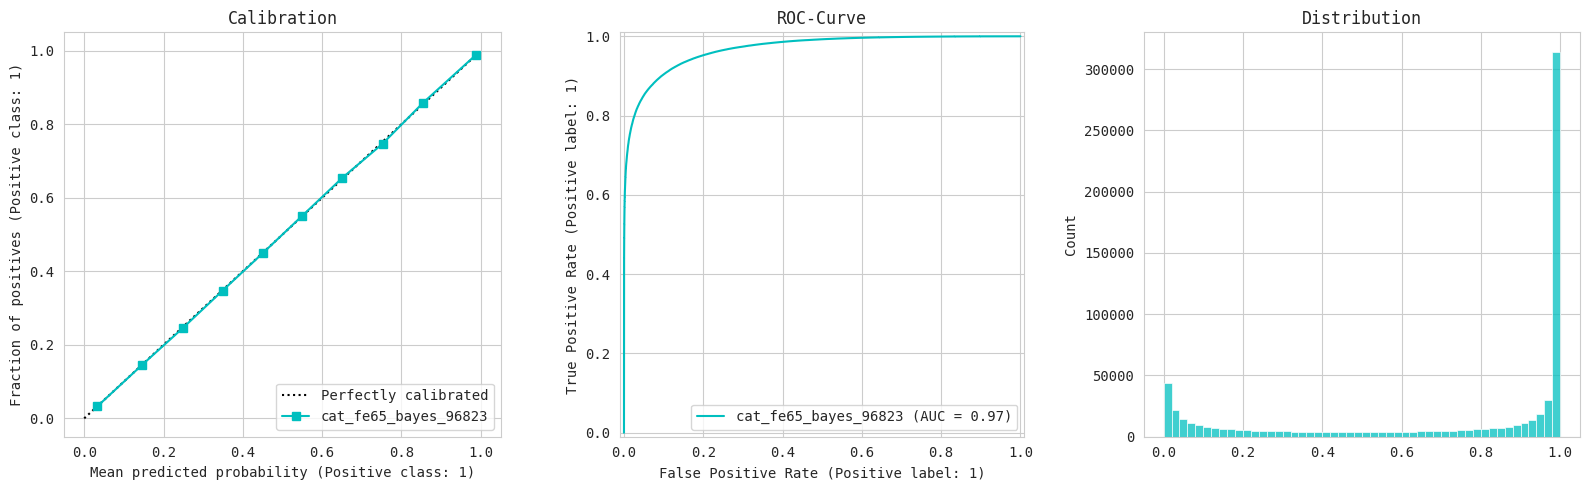


cat_fe65_bern_967512 saved!


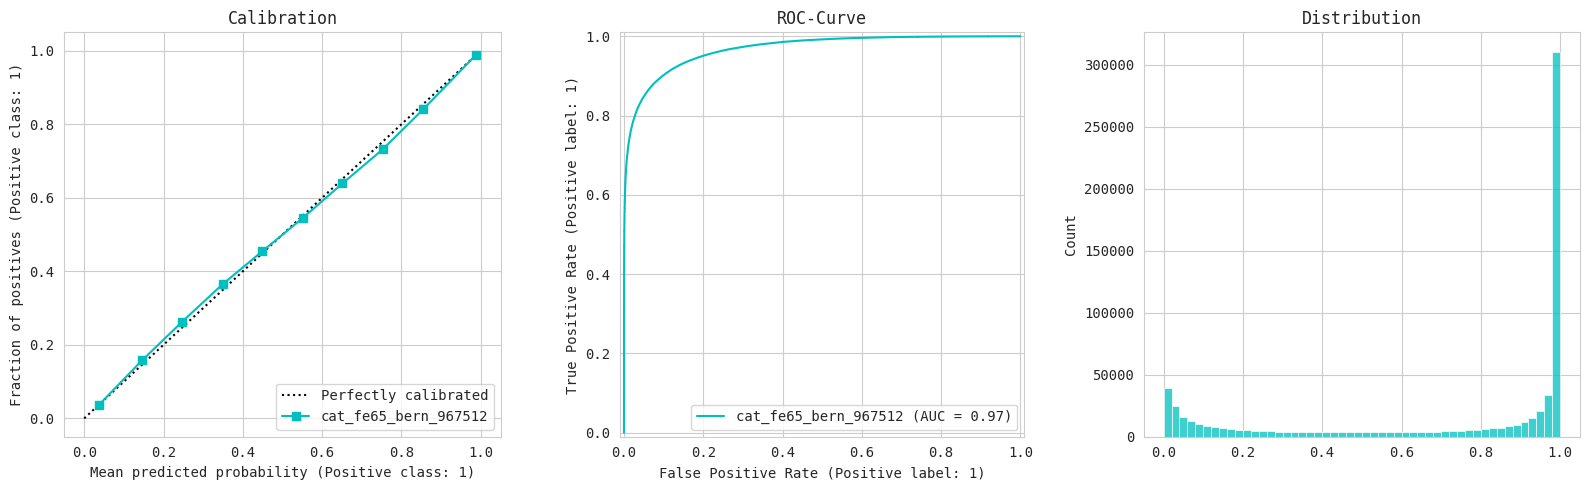


cat_fe65_loss_967883 saved!


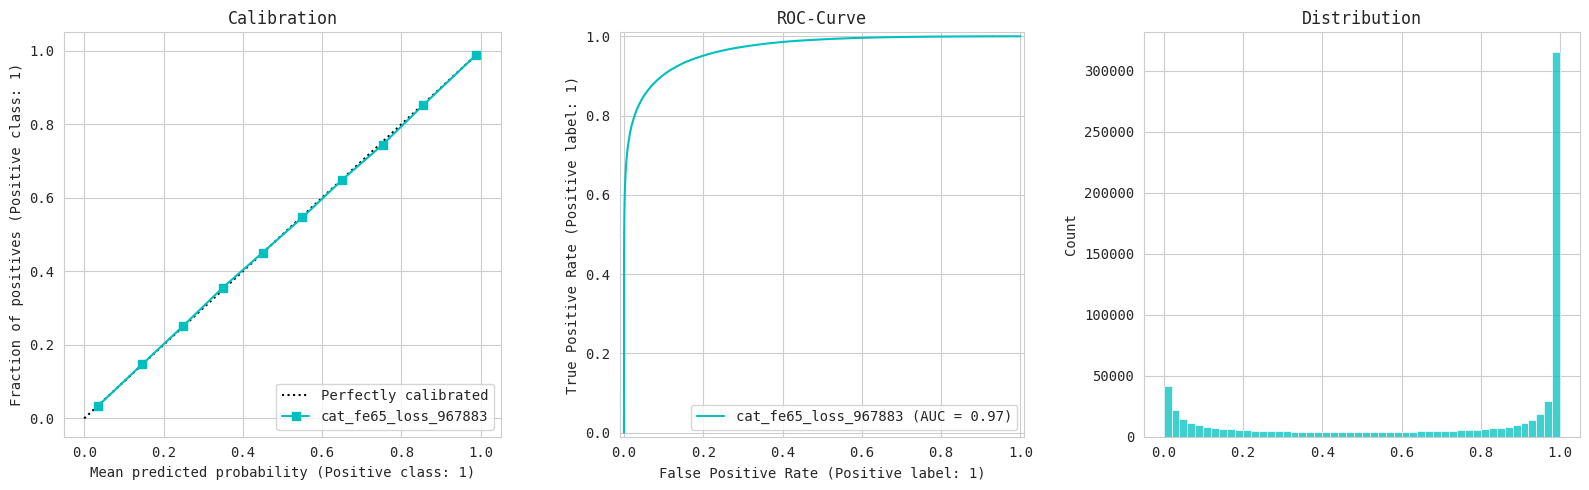


cat_fe65_ord_bayes_968088 saved!


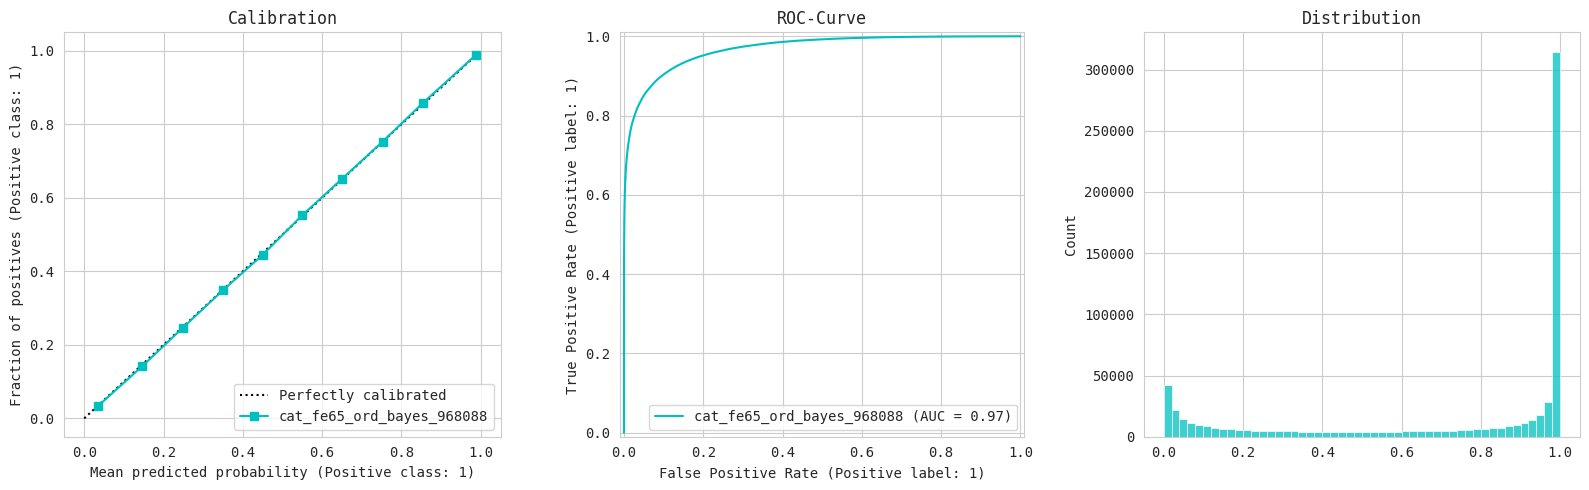

In [45]:
## -- Get oof predictions --

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [46]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

cat_fe65_bayes_96823 saved! (296302,)
cat_fe65_bern_967512 saved! (296302,)
cat_fe65_loss_967883 saved! (296302,)
cat_fe65_ord_bayes_968088 saved! (296302,)



,cat_fe65_bayes,cat_fe65_bern_,cat_fe65_loss_,cat_fe65_ord_bayes_
0,0.999618,0.999147,0.999398,0.999689
1,0.978357,0.974093,0.970641,0.976068
2,0.892251,0.912008,0.905407,0.891593
3,0.994623,0.993460,0.995618,0.995221
4,0.998801,0.996782,0.997705,0.998823
...,...,...,...,...
296297,0.999993,0.999862,1.000000,0.999999
296298,0.766257,0.784253,0.789157,0.732268
296299,0.246100,0.172806,0.179428,0.258025
296300,0.764543,0.759421,0.766297,0.763593


In [47]:
# TE with transformer
# cat_fe30_bayes_95984 saved! (296302,)
# cat_fe30_bern_958693 saved! (296302,)
# cat_fe30_loss_959477 saved! (296302,)
# cat_fe30_ord_bayes_960783 saved! (296302,)

# TE internal CatBoost
# cat_fe80_bayes_960507 saved! (296302,)
# cat_fe80_bern_960261 saved! (296302,)
# cat_fe80_loss_960115 saved! (296302,)
# cat_fe80_ord_bayes_960638 saved! (296302,)

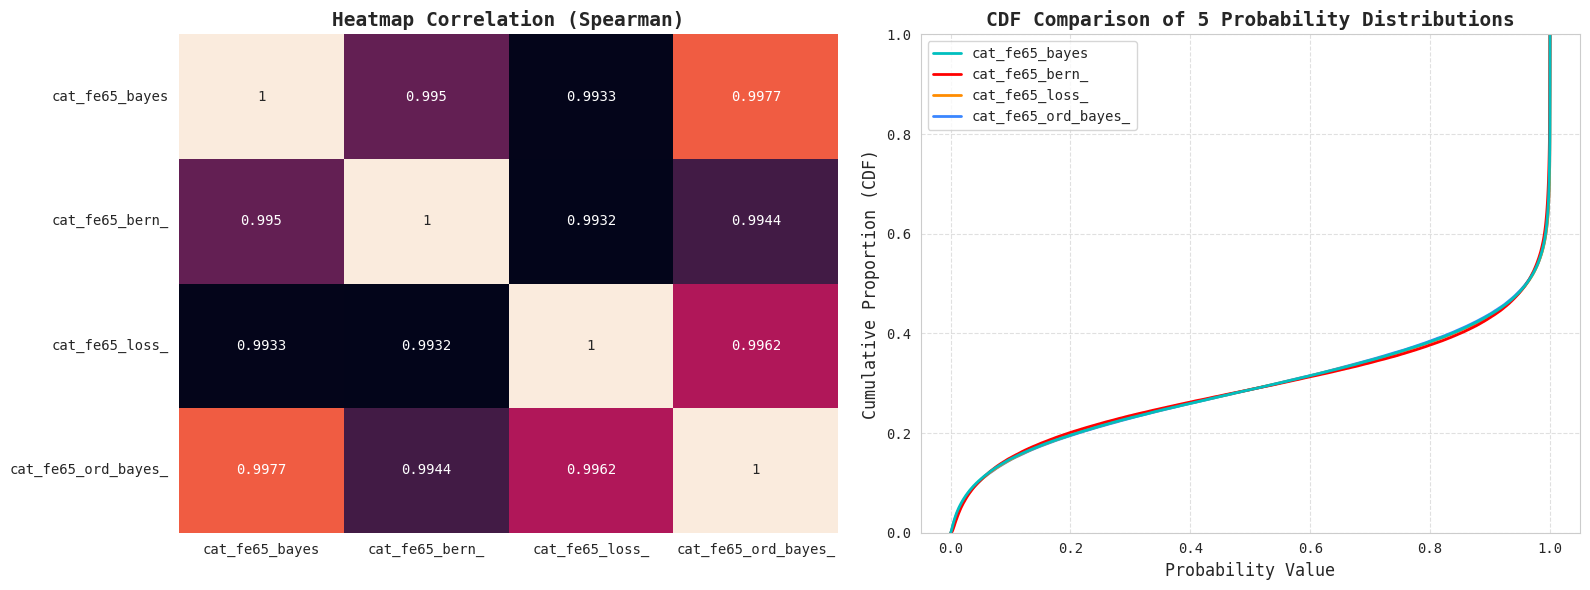

In [48]:
if len(model_results.columns) > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')
    
    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title('CDF Comparison of 5 Probability Distributions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Total used features: 89


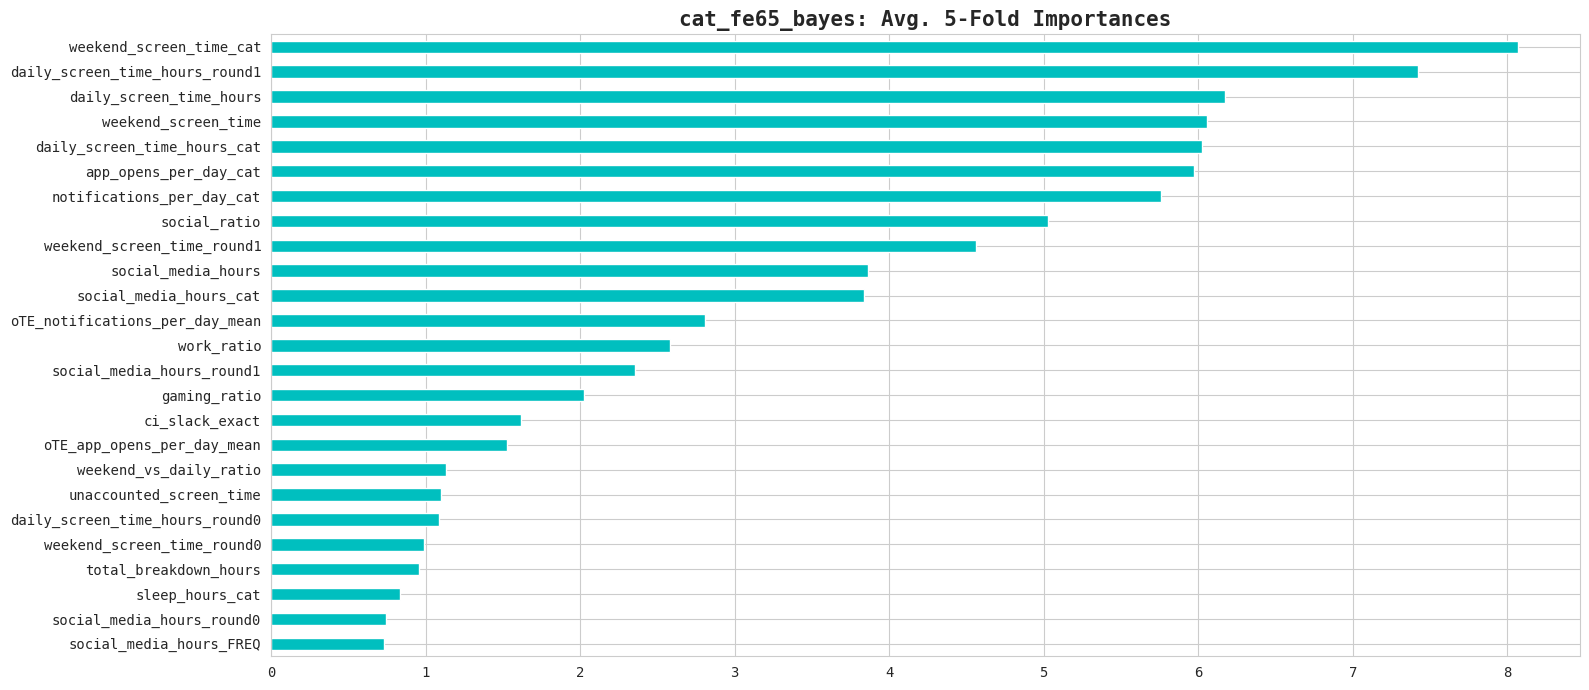


Total used features: 89


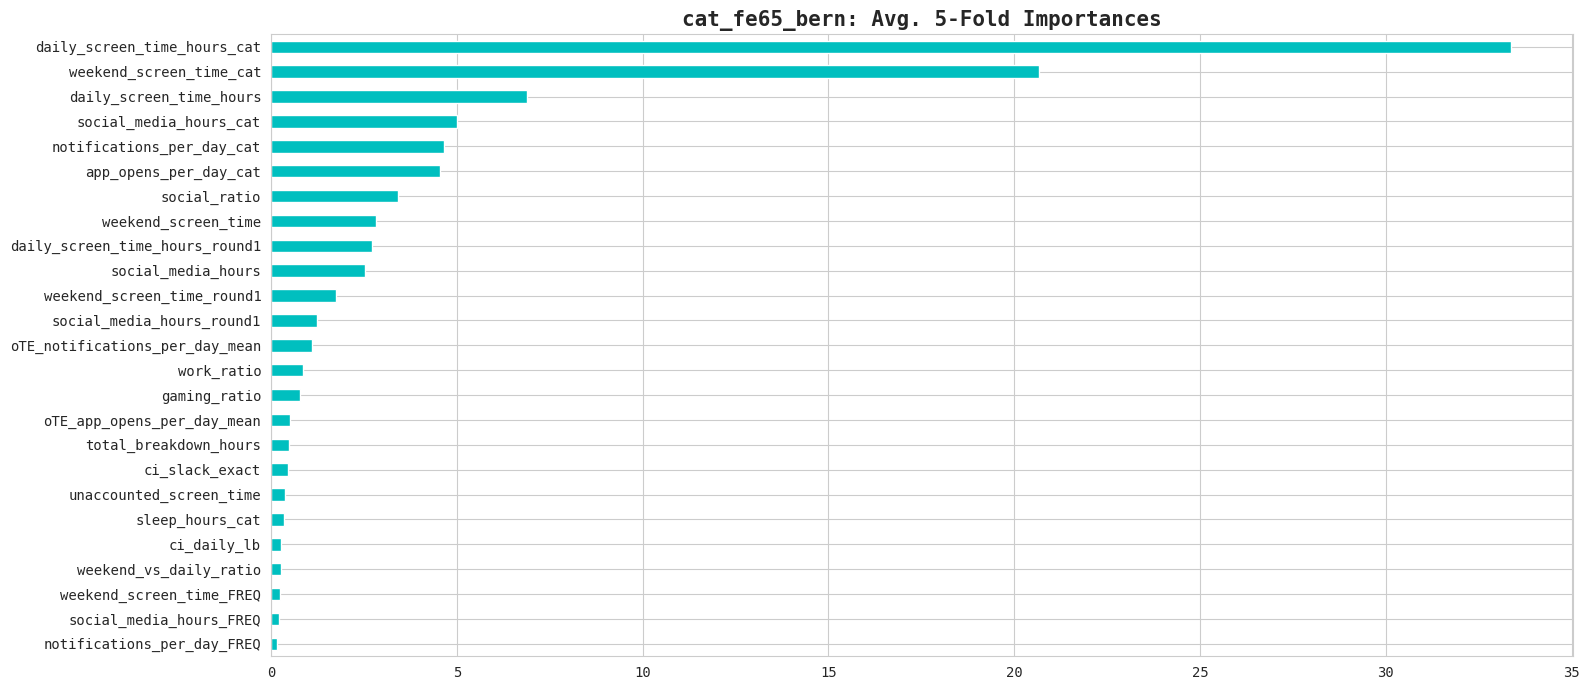


Total used features: 89


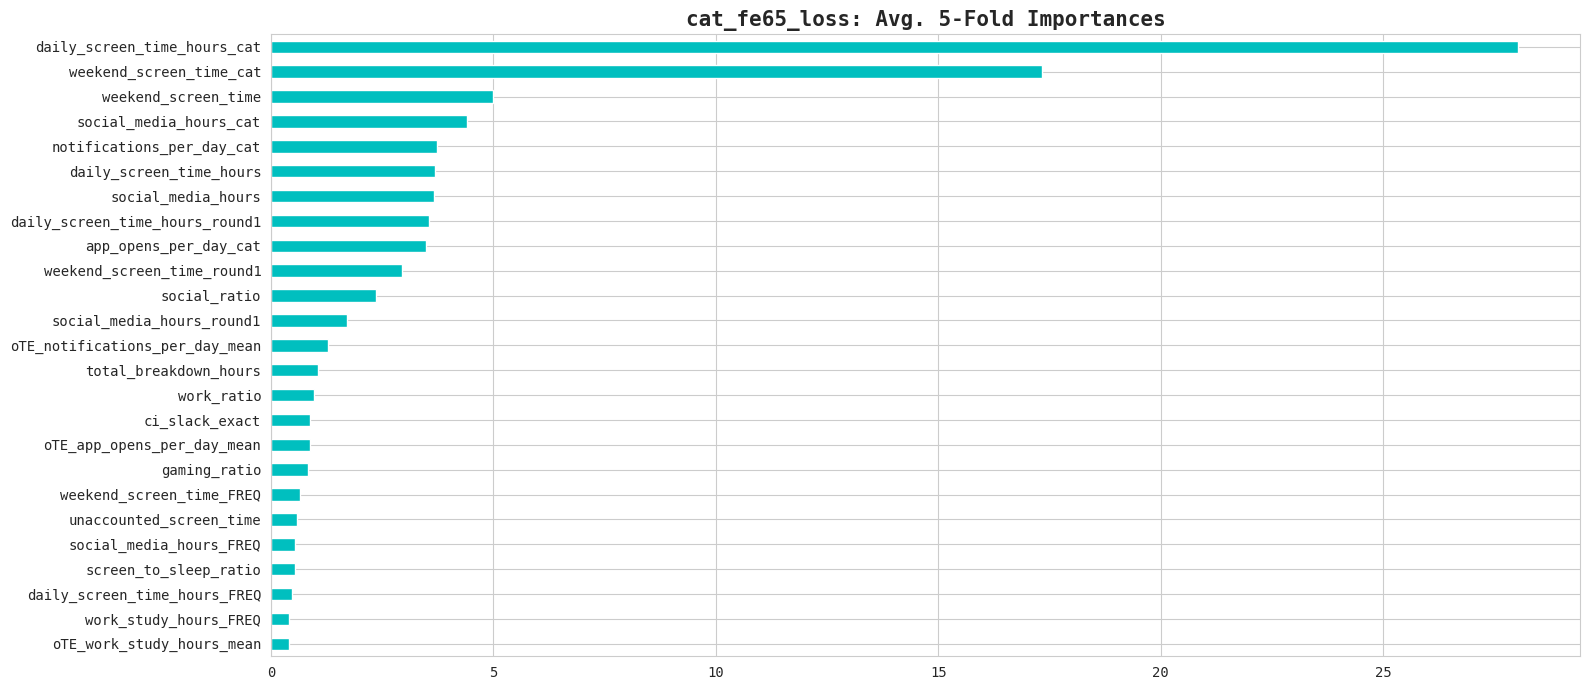


Total used features: 89


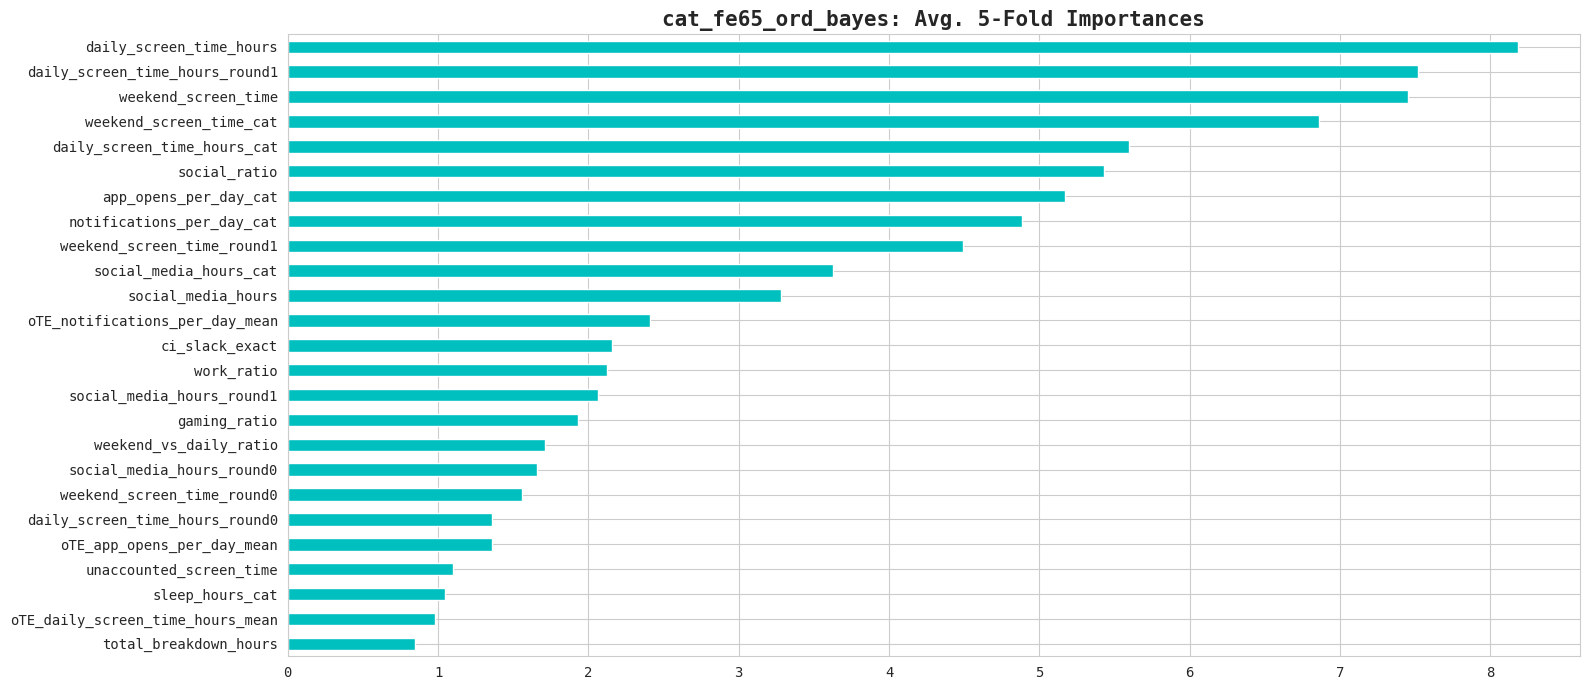

In [49]:
## -- Feature Importances --

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            print(f"Total used features: {len(y)}")
            ax = y.sort_values()[-25:].plot.barh(figsize=(16, 7))
            ax.set_title(f"{k}: Avg. {CFG['FOLDS']}-Fold Importances",
                         fontdict={"size": 15, "weight": "semibold"})
            plt.tight_layout()
            plt.show()
            
            print()

In [50]:
# !rm -r /kaggle/working